In [ ]:
import os
import pandas as pd
from glob import glob
from tqdm import tqdm

from google.colab import drive

drive.mount('/content/drive')

# === Setup ===
image_root_trainval = "/content/drive/MyDrive/Bird_Work_Main/Final_Bird_Image_dataset(fusion)"
audio_root_trainval = "/content/drive/MyDrive/Bird_Work_Main/Final_Bird_Audio_Dataset"

# Allowed audio extensions
audio_exts = ['.wav', '.mp3', '.flac', '.ogg']

# === Helper ===
def get_all_files(folder, exts):
    return [f for ext in exts for f in glob(os.path.join(folder, '**', f'*{ext}'), recursive=True)]

# === Generate pairs ===
def generate_pairs(image_dir, audio_dir, save_path, phases=["Train", "Val"]):
    image_paths = []
    audio_paths = []
    labels = []

    for phase in phases:
        img_root = os.path.join(image_dir, phase)
        aud_root = os.path.join(audio_dir, phase)

        species_list = sorted(os.listdir(img_root))
        for species in species_list:
            img_folder = os.path.join(img_root, species)
            aud_folder = os.path.join(aud_root, species)

            if not os.path.exists(img_folder) or not os.path.exists(aud_folder):
                continue

            img_files = glob(os.path.join(img_folder, "*"))
            aud_files = get_all_files(aud_folder, audio_exts)

            min_len = min(len(img_files), len(aud_files))

            for i in range(min_len):
                image_paths.append(img_files[i])
                audio_paths.append(aud_files[i])
                labels.append(species)

    df = pd.DataFrame({
        "image_path": image_paths,
        "audio_path": audio_paths,
        "label": labels
    })

    df.to_csv(save_path, index=False)
    print(f"✅ Saved {len(df)} samples to {save_path}")
    print("Species in dataset:", df['label'].unique().tolist())

# === Run for Train+Val ===
trainval_csv = "/content/drive/MyDrive/Bird_Work_Main/bird_trainval_pairs.csv"
generate_pairs(image_root_trainval, audio_root_trainval, trainval_csv, phases=["Train", "Val"])

# === Run for Test ===
test_csv = "/content/drive/MyDrive/Bird_Work_Main/bird_test_pairs.csv"
generate_pairs(image_root_trainval, audio_root_trainval, test_csv, phases=["Test"])


Mounted at /content/drive
✅ Saved 436 samples to /content/drive/MyDrive/Bird_Work_Main/bird_trainval_pairs.csv
Species in dataset: ['Common Kingfisher', 'House Crow', 'House Sparrow', 'Indian Peafowl', 'Ruddy Shelduck']
✅ Saved 75 samples to /content/drive/MyDrive/Bird_Work_Main/bird_test_pairs.csv
Species in dataset: ['Common Kingfisher', 'House Crow', 'House Sparrow', 'Indian Peafowl', 'Ruddy Shelduck']


In [ ]:
from google.colab import drive

drive.mount('/content/drive')

import pandas as pd

df_train = pd.read_csv("/content/drive/MyDrive/Bird_Work_Main/bird_trainval_pairs.csv")
df_test = pd.read_csv("/content/drive/MyDrive/Bird_Work_Main/bird_test_pairs.csv")

print("Train Species:", sorted(df_train['label'].unique()))
print("Test Species:", sorted(df_test['label'].unique()))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Train Species: ['Common Kingfisher', 'House Crow', 'House Sparrow', 'Indian Peafowl', 'Ruddy Shelduck']
Test Species: ['Common Kingfisher', 'House Crow', 'House Sparrow', 'Indian Peafowl', 'Ruddy Shelduck']


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=EfficientNet_B4_Weights.IMAGENET1K_V1`. You can also use `weights=EfficientNet_B4_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/efficientnet_b4_rwightman-23ab8bcd.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b4_rwightman-23ab8bcd.pth
100%|██████████| 74.5M/74.5M [00:01<00:00, 73.7MB/s]
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weight

Training species: ['Common Kingfisher', 'House Crow', 'House Sparrow', 'Indian Peafowl', 'Ruddy Shelduck']
Extracting train+val features...


100%|██████████| 436/436 [05:47<00:00,  1.25it/s]


Extracting test features...


100%|██████████| 75/75 [01:06<00:00,  1.13it/s]


Epoch 1/20, Loss: 2.2613
Epoch 2/20, Loss: 1.5693
Epoch 3/20, Loss: 1.2358
Epoch 4/20, Loss: 0.7613
Epoch 5/20, Loss: 0.6987
Epoch 6/20, Loss: 0.5403
Epoch 7/20, Loss: 0.5136
Epoch 8/20, Loss: 0.4304
Epoch 9/20, Loss: 0.4887
Epoch 10/20, Loss: 0.4283
Epoch 11/20, Loss: 0.3179
Epoch 12/20, Loss: 0.2813
Epoch 13/20, Loss: 0.2417
Epoch 14/20, Loss: 0.3253
Epoch 15/20, Loss: 0.3267
Epoch 16/20, Loss: 0.3490
Epoch 17/20, Loss: 0.3283
Epoch 18/20, Loss: 0.3476
Epoch 19/20, Loss: 0.2401
Epoch 20/20, Loss: 0.2731
Test Accuracy: 0.9466666666666667
Classification Report:
                    precision    recall  f1-score   support

Common Kingfisher       0.93      0.93      0.93        15
       House Crow       0.92      0.80      0.86        15
    House Sparrow       0.88      1.00      0.94        15
   Indian Peafowl       1.00      1.00      1.00        15
   Ruddy Shelduck       1.00      1.00      1.00        15

         accuracy                           0.95        75
        macro av

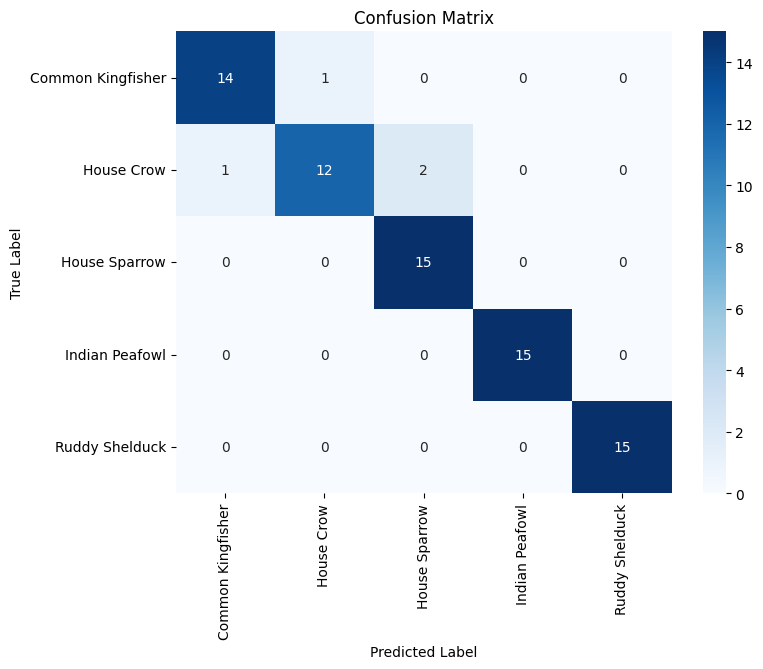

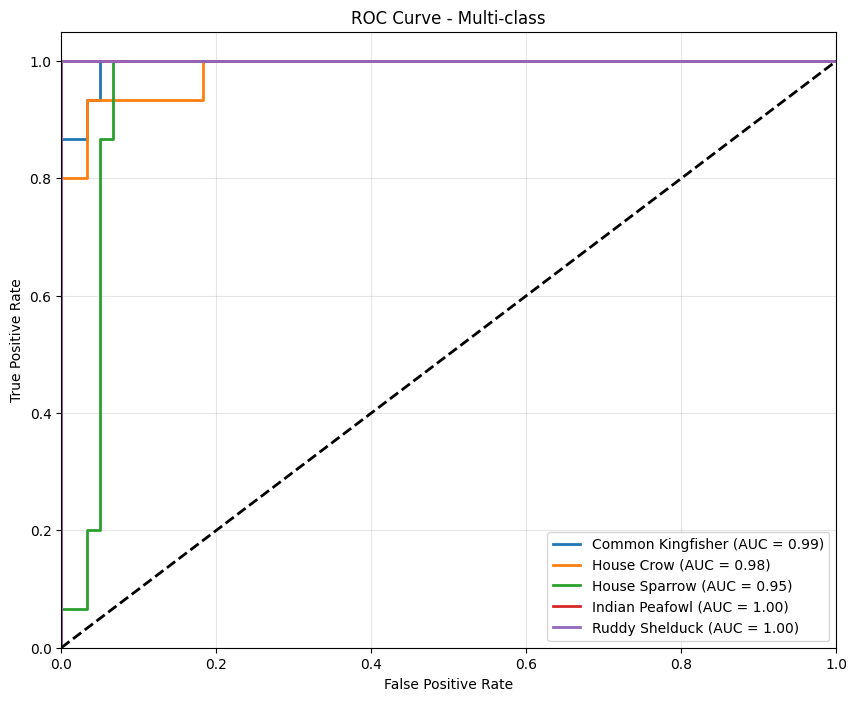

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import models, transforms
import torchaudio
import pandas as pd
import numpy as np
from PIL import Image
from tqdm import tqdm
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import label_binarize
from google.colab import drive

drive.mount('/content/drive')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# === Step 1: Define models ===

# EfficientNet-B4 (image)
image_model = models.efficientnet_b4(pretrained=True)
image_model.classifier = torch.nn.Identity()  # Remove classifier to get features
image_model.to(device).eval()

# ConvNeXt-Large (mel spectrogram)
mel_model = models.convnext_large(pretrained=True)
mel_model.classifier = torch.nn.Identity()
mel_model.to(device).eval()

# MobileNetV3-Large (MFCC)
mfcc_model = models.mobilenet_v3_large(pretrained=True)
mfcc_model.classifier = torch.nn.Identity()
mfcc_model.to(device).eval()

# === Step 2: Define transforms ===

image_transform = transforms.Compose([
    transforms.Resize((380, 380)),  # EfficientNet-B4 input size
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

mel_transform = torchaudio.transforms.MelSpectrogram(
    sample_rate=16000, n_mels=128, n_fft=1024, hop_length=512
)
mfcc_transform = torchaudio.transforms.MFCC(
    sample_rate=16000, n_mfcc=40, melkwargs={'n_fft':1024, 'hop_length':512, 'n_mels':128}
)

def flatten_features(x):
    if x.dim() > 2:
        return x.flatten(1)
    return x

# === Step 3: Feature extraction function ===

def extract_features(df, label_map):
    all_features = []
    all_labels = []

    for idx, row in tqdm(df.iterrows(), total=len(df)):
        image_path = row['image_path']
        audio_path = row['audio_path']
        label = label_map[row['label']]

        # Load and transform image
        image = Image.open(image_path).convert("RGB")
        image_tensor = image_transform(image).unsqueeze(0).to(device)

        # Load and preprocess audio
        waveform, sr = torchaudio.load(audio_path)
        if sr != 16000:
            waveform = torchaudio.transforms.Resample(orig_freq=sr, new_freq=16000)(waveform)
        if waveform.shape[0] > 1:
            waveform = waveform.mean(dim=0, keepdim=True)

        mel = mel_transform(waveform)
        mel = F.pad(mel, (0, max(0, 400 - mel.shape[-1])))[:, :, :400].unsqueeze(0).to(device)

        mfcc = mfcc_transform(waveform)
        mfcc = F.pad(mfcc, (0, max(0, 400 - mfcc.shape[-1])))[:, :, :400].unsqueeze(0).to(device)

        mel = mel.repeat(1, 3, 1, 1)    # Repeat channel 1 to 3 for mel
        mfcc = mfcc.repeat(1, 3, 1, 1)  # Repeat channel 1 to 3 for mfcc

        # Extract features
        with torch.no_grad():
            img_feat = flatten_features(image_model(image_tensor))
            mel_feat = flatten_features(mel_model(mel))
            mfcc_feat = flatten_features(mfcc_model(mfcc))

        combined = torch.cat([img_feat, mel_feat, mfcc_feat], dim=1).cpu().squeeze(0).numpy()
        all_features.append(combined)
        all_labels.append(label)

    X = np.stack(all_features)
    y = np.array(all_labels)
    return X, y

# === Step 4: Load CSVs and prepare datasets ===

train_csv_path = "/content/drive/MyDrive/Bird_Work_Main/bird_trainval_pairs.csv"
test_csv_path = "/content/drive/MyDrive/Bird_Work_Main/bird_test_pairs.csv"

train_df = pd.read_csv(train_csv_path)
test_df = pd.read_csv(test_csv_path)

species_list = sorted(train_df['label'].unique())
label_map = {name: idx for idx, name in enumerate(species_list)}

print("Training species:", species_list)

print("Extracting train+val features...")
X_train, y_train = extract_features(train_df, label_map)

print("Extracting test features...")
X_test, y_test = extract_features(test_df, label_map)

# === Step 5: Define the simple NN classifier ===

class SimpleNN(nn.Module):
    def __init__(self, input_dim, num_classes):
        super(SimpleNN, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 512),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes)
        )
    def forward(self, x):
        return self.net(x)

input_dim = X_train.shape[1]
num_classes = len(species_list)

model = SimpleNN(input_dim, num_classes).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

# Convert numpy arrays to torch tensors
X_train_t = torch.tensor(X_train).float()
y_train_t = torch.tensor(y_train).long()
X_test_t = torch.tensor(X_test).float()
y_test_t = torch.tensor(y_test).long()

from torch.utils.data import TensorDataset, DataLoader

train_ds = TensorDataset(X_train_t, y_train_t)
train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)

# === Step 6: Train the NN ===

model.train()
epochs = 20
for epoch in range(epochs):
    total_loss = 0
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        out = model(xb)
        loss = criterion(out, yb)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    print(f"Epoch {epoch+1}/{epochs}, Loss: {total_loss/len(train_loader):.4f}")

# === Step 7: Evaluate the NN ===

model.eval()
with torch.no_grad():
    X_test_t = X_test_t.to(device)
    outputs = model(X_test_t)
    _, preds = torch.max(outputs, 1)
    preds = preds.cpu().numpy()

print("Test Accuracy:", (preds == y_test).mean())
print("Classification Report:\n", classification_report(y_test, preds, target_names=species_list))

cm = confusion_matrix(y_test, preds)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=species_list, yticklabels=species_list)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

# ROC Curve for each class
y_test_binarized = label_binarize(y_test, classes=range(len(species_list)))
y_score = outputs.cpu().numpy()  # raw logits before softmax

plt.figure(figsize=(10,8))
from sklearn.metrics import roc_curve, auc
for i, species in enumerate(species_list):
    fpr, tpr, _ = roc_curve(y_test_binarized[:, i], y_score[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, lw=2, label=f'{species} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Multi-class')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()


In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score

# Precision, Recall, F1 Score
precision_macro = precision_score(y_test, preds, average='macro')
recall_macro = recall_score(y_test, preds, average='macro')
f1_macro = f1_score(y_test, preds, average='macro')

precision_micro = precision_score(y_test, preds, average='micro')
recall_micro = recall_score(y_test, preds, average='micro')
f1_micro = f1_score(y_test, preds, average='micro')

precision_weighted = precision_score(y_test, preds, average='weighted')
recall_weighted = recall_score(y_test, preds, average='weighted')
f1_weighted = f1_score(y_test, preds, average='weighted')

print("\n--- Evaluation Metrics ---")
print(f"Precision (Macro):   {precision_macro:.4f}")
print(f"Recall (Macro):      {recall_macro:.4f}")
print(f"F1 Score (Macro):    {f1_macro:.4f}")
print(f"Precision (Micro):   {precision_micro:.4f}")
print(f"Recall (Micro):      {recall_micro:.4f}")
print(f"F1 Score (Micro):    {f1_micro:.4f}")
print(f"Precision (Weighted):{precision_weighted:.4f}")
print(f"Recall (Weighted):   {recall_weighted:.4f}")
print(f"F1 Score (Weighted): {f1_weighted:.4f}")



--- Evaluation Metrics ---
Precision (Macro):   0.9478
Recall (Macro):      0.9467
F1 Score (Macro):    0.9456
Precision (Micro):   0.9467
Recall (Micro):      0.9467
F1 Score (Micro):    0.9467
Precision (Weighted):0.9478
Recall (Weighted):   0.9467
F1 Score (Weighted): 0.9456


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=EfficientNet_B4_Weights.IMAGENET1K_V1`. You can also use `weights=EfficientNet_B4_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ConvNeXt_Large_Weights.IMAGENET1K_V1`. You can also use `weights=ConvNeXt_Large_Weights.DEFAULT` to ge

Training species: ['Common Kingfisher', 'House Crow', 'House Sparrow', 'Indian Peafowl', 'Ruddy Shelduck']
Extracting train+val features...


100%|██████████| 436/436 [00:56<00:00,  7.69it/s]


Extracting test features...


100%|██████████| 75/75 [00:09<00:00,  7.76it/s]


Epoch 1/20, Loss: 2.6738
Epoch 2/20, Loss: 1.1055
Epoch 3/20, Loss: 1.0521
Epoch 4/20, Loss: 0.7309
Epoch 5/20, Loss: 0.6403
Epoch 6/20, Loss: 0.5410
Epoch 7/20, Loss: 0.5532
Epoch 8/20, Loss: 0.4220
Epoch 9/20, Loss: 0.3903
Epoch 10/20, Loss: 0.3391
Epoch 11/20, Loss: 0.3333
Epoch 12/20, Loss: 0.3707
Epoch 13/20, Loss: 0.3811
Epoch 14/20, Loss: 0.3808
Epoch 15/20, Loss: 0.3605
Epoch 16/20, Loss: 0.2300
Epoch 17/20, Loss: 0.2722
Epoch 18/20, Loss: 0.2160
Epoch 19/20, Loss: 0.2411
Epoch 20/20, Loss: 0.2284

⏱ Training Time: 0.7531 seconds
⏱ Testing Time: 0.0010 seconds

✅ Test Accuracy: 0.9733333333333334
📊 Classification Report:
                    precision    recall  f1-score   support

Common Kingfisher       0.88      1.00      0.94        15
       House Crow       1.00      0.87      0.93        15
    House Sparrow       1.00      1.00      1.00        15
   Indian Peafowl       1.00      1.00      1.00        15
   Ruddy Shelduck       1.00      1.00      1.00        15

      

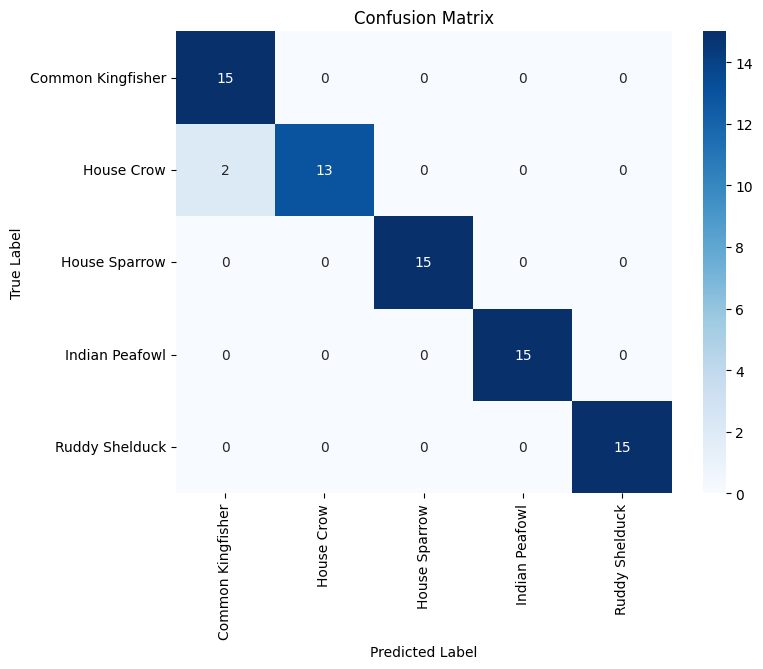

/usr/local/lib/python3.11/dist-packages/scipy/interpolate/_interpolate.py:479: RuntimeWarning: divide by zero encountered in divide
  slope = (y_hi - y_lo) / (x_hi - x_lo)[:, None]
/usr/local/lib/python3.11/dist-packages/scipy/interpolate/_interpolate.py:482: RuntimeWarning: invalid value encountered in multiply
  y_new = slope*(x_new - x_lo)[:, None] + y_lo
/usr/local/lib/python3.11/dist-packages/scipy/interpolate/_interpolate.py:479: RuntimeWarning: divide by zero encountered in divide
  slope = (y_hi - y_lo) / (x_hi - x_lo)[:, None]
/usr/local/lib/python3.11/dist-packages/scipy/interpolate/_interpolate.py:482: RuntimeWarning: invalid value encountered in multiply
  y_new = slope*(x_new - x_lo)[:, None] + y_lo
/usr/local/lib/python3.11/dist-packages/scipy/interpolate/_interpolate.py:479: RuntimeWarning: divide by zero encountered in divide
  slope = (y_hi - y_lo) / (x_hi - x_lo)[:, None]
/usr/local/lib/python3.11/dist-packages/scipy/interpolate/_interpolate.py:482: RuntimeWarning: in

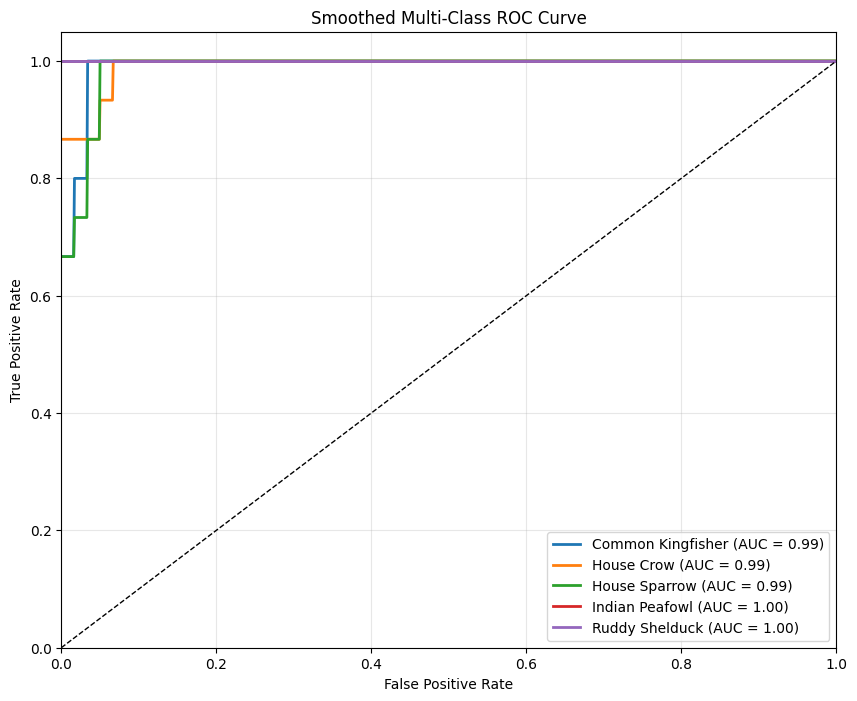


--- Evaluation Metrics ---
Precision (macro): 0.9765
Recall    (macro): 0.9733
F1 Score  (macro): 0.9732
Precision (micro): 0.9733
Recall    (micro): 0.9733
F1 Score  (micro): 0.9733
Precision (weighted): 0.9765
Recall    (weighted): 0.9733
F1 Score  (weighted): 0.9732


In [3]:
import time
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import models, transforms
import torchaudio
import pandas as pd
import numpy as np
from PIL import Image
from tqdm import tqdm
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc, precision_score, recall_score, f1_score
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import label_binarize
from google.colab import drive

drive.mount('/content/drive')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# === Step 1: Define models ===
image_model = models.efficientnet_b4(pretrained=True)
image_model.classifier = nn.Identity()
image_model.to(device).eval()

mel_model = models.convnext_large(pretrained=True)
mel_model.classifier = nn.Identity()
mel_model.to(device).eval()

mfcc_model = models.mobilenet_v3_large(pretrained=True)
mfcc_model.classifier = nn.Identity()
mfcc_model.to(device).eval()

# === Step 2: Define transforms ===
image_transform = transforms.Compose([
    transforms.Resize((380, 380)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

mel_transform = torchaudio.transforms.MelSpectrogram(
    sample_rate=16000, n_mels=128, n_fft=1024, hop_length=512
)
mfcc_transform = torchaudio.transforms.MFCC(
    sample_rate=16000, n_mfcc=40, melkwargs={'n_fft':1024, 'hop_length':512, 'n_mels':128}
)

def flatten_features(x):
    if x.dim() > 2:
        return x.flatten(1)
    return x

# === Step 3: Feature extraction ===
def extract_features(df, label_map):
    all_features, all_labels = [], []

    for idx, row in tqdm(df.iterrows(), total=len(df)):
        image_path, audio_path, label = row['image_path'], row['audio_path'], label_map[row['label']]

        image = Image.open(image_path).convert("RGB")
        image_tensor = image_transform(image).unsqueeze(0).to(device)

        waveform, sr = torchaudio.load(audio_path)
        if sr != 16000:
            waveform = torchaudio.transforms.Resample(sr, 16000)(waveform)
        if waveform.shape[0] > 1:
            waveform = waveform.mean(dim=0, keepdim=True)

        mel = mel_transform(waveform)
        mel = F.pad(mel, (0, max(0, 400 - mel.shape[-1])))[:, :, :400].unsqueeze(0).to(device)
        mel = mel.repeat(1, 3, 1, 1)

        mfcc = mfcc_transform(waveform)
        mfcc = F.pad(mfcc, (0, max(0, 400 - mfcc.shape[-1])))[:, :, :400].unsqueeze(0).to(device)
        mfcc = mfcc.repeat(1, 3, 1, 1)

        with torch.no_grad():
            img_feat = flatten_features(image_model(image_tensor))
            mel_feat = flatten_features(mel_model(mel))
            mfcc_feat = flatten_features(mfcc_model(mfcc))

        combined = torch.cat([img_feat, mel_feat, mfcc_feat], dim=1).cpu().squeeze(0).numpy()
        all_features.append(combined)
        all_labels.append(label)

    return np.stack(all_features), np.array(all_labels)

# === Step 4: Load data ===
train_df = pd.read_csv("/content/drive/MyDrive/Bird_Work_Main/bird_trainval_pairs.csv")
test_df = pd.read_csv("/content/drive/MyDrive/Bird_Work_Main/bird_test_pairs.csv")

species_list = sorted(train_df['label'].unique())
label_map = {name: idx for idx, name in enumerate(species_list)}

print("Training species:", species_list)

print("Extracting train+val features...")
X_train, y_train = extract_features(train_df, label_map)

print("Extracting test features...")
X_test, y_test = extract_features(test_df, label_map)

# === Step 5: Define classifier ===
class SimpleNN(nn.Module):
    def __init__(self, input_dim, num_classes):
        super(SimpleNN, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 512),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes)
        )
    def forward(self, x):
        return self.net(x)

input_dim = X_train.shape[1]
num_classes = len(species_list)

model = SimpleNN(input_dim, num_classes).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

X_train_t = torch.tensor(X_train).float()
y_train_t = torch.tensor(y_train).long()
X_test_t = torch.tensor(X_test).float()
y_test_t = torch.tensor(y_test).long()

from torch.utils.data import TensorDataset, DataLoader
train_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=32, shuffle=True)

import time

# === Step 6: Train with time ===
start_train = time.perf_counter()
model.train()
for epoch in range(20):
    total_loss = 0
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        loss = criterion(model(xb), yb)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    print(f"Epoch {epoch+1}/20, Loss: {total_loss/len(train_loader):.4f}")
end_train = time.perf_counter()
print(f"\n⏱ Training Time: {end_train - start_train:.4f} seconds")

# === Step 7: Test with time ===
start_test = time.perf_counter()
model.eval()
with torch.no_grad():
    X_test_t = X_test_t.to(device)
    outputs = model(X_test_t)
    _, preds = torch.max(outputs, 1)
    preds = preds.cpu().numpy()
end_test = time.perf_counter()
print(f"⏱ Testing Time: {end_test - start_test:.4f} seconds")


# === Step 8: Metrics ===
print("\n✅ Test Accuracy:", (preds == y_test).mean())
print("📊 Classification Report:\n", classification_report(y_test, preds, target_names=species_list))

# Confusion Matrix
cm = confusion_matrix(y_test, preds)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=species_list, yticklabels=species_list)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
from scipy.interpolate import interp1d

# Binarize the test labels for multi-class ROC
y_test_bin = label_binarize(y_test, classes=range(num_classes))
y_score = outputs.cpu().numpy()

# Plot smoothed ROC
plt.figure(figsize=(10, 8))

for i, species in enumerate(species_list):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc = auc(fpr, tpr)

    # Interpolation for smoothing
    interp_fpr = np.linspace(0, 1, 1000)
    interp_tpr_func = interp1d(fpr, tpr, kind='linear', fill_value="extrapolate")
    interp_tpr = interp_tpr_func(interp_fpr)

    plt.plot(interp_fpr, interp_tpr, label=f'{species} (AUC = {roc_auc:.2f})', lw=2)

plt.plot([0, 1], [0, 1], 'k--', lw=1)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Smoothed Multi-Class ROC Curve')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()


# Precision, Recall, F1
print("\n--- Evaluation Metrics ---")
for avg in ['macro', 'micro', 'weighted']:
    print(f"Precision ({avg}): {precision_score(y_test, preds, average=avg):.4f}")
    print(f"Recall    ({avg}): {recall_score(y_test, preds, average=avg):.4f}")
    print(f"F1 Score  ({avg}): {f1_score(y_test, preds, average=avg):.4f}")
